In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 5000
departements = ['Support client', 'Commercial', 'RH', 'Finance', 'IT', 'Marketing', 'Operations']
niveaux = ['Junior', 'Confirmé', 'Senior', 'Manager']

df = pd.DataFrame({
    'employe_id': range(1, n + 1),
    'departement': np.random.choice(departements, n, p=[0.25, 0.20, 0.10, 0.10, 0.15, 0.10, 0.10]),
    'niveau': np.random.choice(niveaux, n, p=[0.35, 0.30, 0.25, 0.10]),
    'anciennete_ans': np.random.exponential(scale=4, size=n).clip(0, 20).round(1),
    'salaire': np.random.normal(42000, 12000, n).clip(24000, 95000).round(-2),
    'score_performance': np.random.normal(6.2, 2.1, n).clip(1, 10).round(1),
    'jours_absence': np.random.poisson(lam=7, size=n).clip(0, 40),
    'a_quitte': np.random.choice([0, 1], n, p=[0.857, 0.143]),
})
mask = df['score_performance'] < 3
df.loc[mask, 'a_quitte'] = np.random.choice([0, 1], mask.sum(), p=[0.40, 0.60])

df.head()


,employe_id,departement,niveau,anciennete_ans,salaire,score_performance,jours_absence,a_quitte
0,1,Commercial,Confirmé,1.9,62200.0,3.7,5,0
1,2,Operations,Confirmé,1.6,42000.0,8.3,5,0
2,3,IT,Senior,0.8,32200.0,8.8,3,0
3,4,Finance,Junior,3.7,43500.0,6.4,3,0
4,5,Support client,Senior,2.6,35400.0,10.0,7,0


In [24]:

taux = df['a_quitte'].mean() * 100
print(f"Taux de turnover global : {taux:.1f}%")


Taux de turnover global : 16.5%


/tmp/ipykernel_5831/2645993310.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




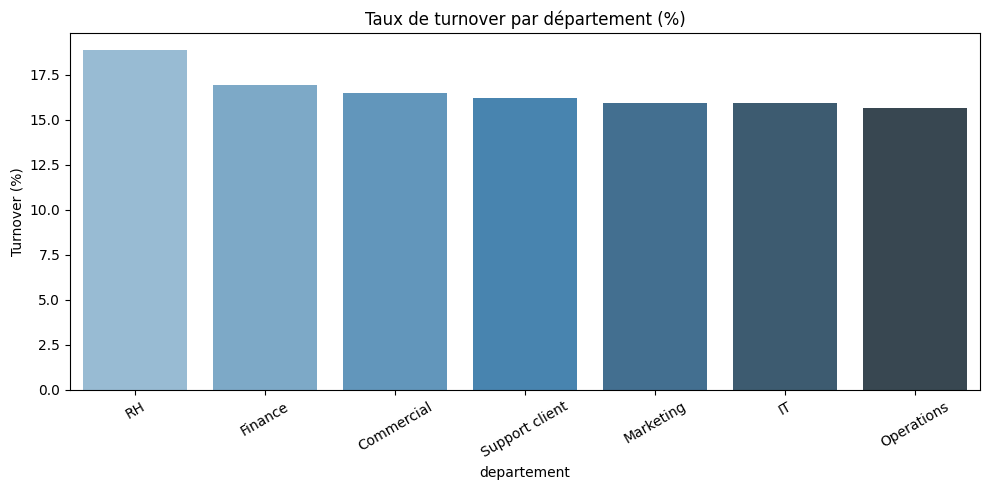

In [25]:
%matplotlib inline
turnover_dept = df.groupby('departement')['a_quitte'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=turnover_dept.index, y=turnover_dept.values, palette='Blues_d')
plt.title('Taux de turnover par département (%)')
plt.ylabel('Turnover (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5831/2479951237.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




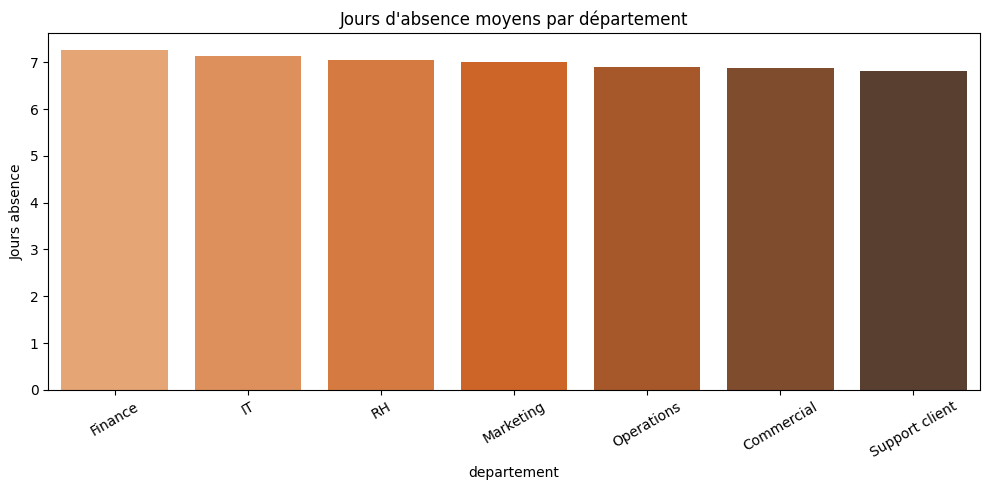

In [26]:
absence_dept = df.groupby('departement')['jours_absence'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=absence_dept.index, y=absence_dept.values, palette='Oranges_d')
plt.title("Jours d'absence moyens par département")
plt.ylabel('Jours absence')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5831/260449565.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_5831/260449565.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




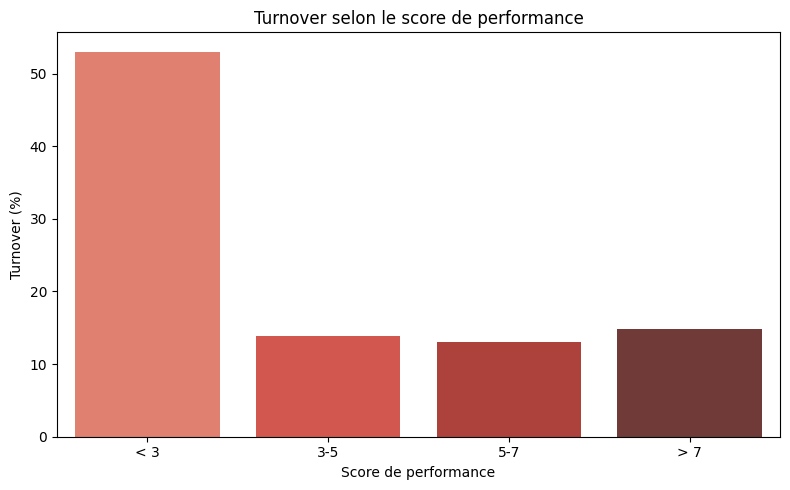

In [27]:

df['score_bin'] = pd.cut(df['score_performance'], bins=[0,3,5,7,10], labels=['< 3','3-5','5-7','> 7'])
turnover_perf = df.groupby('score_bin')['a_quitte'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=turnover_perf.index, y=turnover_perf.values, palette='Reds_d')
plt.title('Turnover selon le score de performance')
plt.ylabel('Turnover (%)')
plt.xlabel('Score de performance')
plt.tight_layout()
plt.show()

In [29]:
# Vérification
dept_turnover = df.groupby('departement')['a_quitte'].mean().sort_values(ascending=False) * 100
dept_absence = df.groupby('departement')['jours_absence'].mean().sort_values(ascending=False)

print("=== Turnover par département ===")
print(dept_turnover.round(1))
print("\n=== Absences par département ===")
print(dept_absence.round(1))
print(f"\nDépartement avec le + de turnover : {dept_turnover.index[0]}")
print(f"Département avec le + d'absences : {dept_absence.index[0]}")

=== Turnover par département ===
departement
RH                18.9
Finance           17.0
Commercial        16.5
Support client    16.2
Marketing         16.0
IT                15.9
Operations        15.7
Name: a_quitte, dtype: float64

=== Absences par département ===
departement
Finance           7.3
IT                7.1
RH                7.1
Marketing         7.0
Operations        6.9
Commercial        6.9
Support client    6.8
Name: jours_absence, dtype: float64

Département avec le + de turnover : RH
Département avec le + d'absences : Finance
